<div style="text-align: center;">
    <a href="https://www.hi-paris.fr/">
        <img border="0" src="https://www.hi-paris.fr/wp-content/uploads/2020/09/logo-hi-paris-retina.png" width="25%"></a>
    <a href="https://www.dataia.eu/">
        <img border="0" src="https://github.com/ramp-kits/template-kit/raw/main/img/DATAIA-h.png" width="70%"></a>
</div>

# GEMS-GER Groundwater Level Prediction Challenge

## Introduction
Groundwater is a critical resource for drinking water and agriculture. This challenge uses the **GEMS-GER** dataset, which provides historical groundwater levels (GWL) and over 50 environmental features (meteorological and static site data) across Germany.

**The Task:** Predict the depth to groundwater (GWL) for various monitoring wells.
**The Metric:** Root Mean Squared Error (RMSE). Lower is better.

<i> Youssef SIDHOM</i> </br>
<i> Ralph  MOUAWAD</i> </br>
<i> Spyridon PAIPETIS</i> </br>
<i> Charles KARRER</i> </br>
<i> Clément DESTOUESSE</i> </br>
<i> Felix BLANCHARD</i> </br>

## 📊 Data Source & Attribution

This challenge utilizes the **GEMS-GER (Groundwater Levels, Environment, Meteorology, and Site Properties for Germany)** dataset, a multi-source benchmark for groundwater level prediction.

### **Dataset Overview**

* **Source:** [Copernicus ESSD / Zenodo](https://doi.org/10.5281/zenodo.15530171)
* **Temporal Coverage:** Filtered for the most recent 5 years (2021–2026).
* **Spatial Coverage:** 3,200+ monitoring wells across Germany.
* **Features:** Includes 50+ static environmental variables (geology, soil, topography) and dynamic meteorological drivers (HYRAS, ERA5, and DWD products).

### **Data Citation**

If you use this data or the results of this challenge in your own research, please cite the original authors:

> *Benz, S. A., et al. (2026). GEMS-GER: A machine learning benchmark dataset for groundwater level modeling in Germany. Earth System Science Data (ESSD).*

### **License**

This dataset is provided under the **Creative Commons Attribution 4.0 International (CC BY 4.0)** license. You are free to share and adapt the material as long as appropriate credit is given.

---

# Getting Started
Before loading data, we run the setup script to download and split the dataset.

In [1]:
# Run the setup script to download and prepare the folders
!python tools/setup_data.py

📥 Downloading dataset...
📊 Merging and optimizing memory...
🚀 Setup Complete!
Train: 1,000,000
Dev Test: 50,000
Final Test: 50,000


# Exploratory data analysis

The goal of this section is to show what's in the data, and how to play with it.
This is the first set in any data science project, and here, you should give a sense of the data the participants will be working with.

You can first load and describe the data, and then show some interesting properties of it.

In [16]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Load the data
from ingestion_program.ingestion import get_train_data
X_df, y = get_train_data("dev_phase/input_data")

Reading training data in chunks of 200000...


In [17]:
print("DATASET OVERVIEW")
print("="*80)
print(f"\nShape: {X_df.shape}")
print(f"Target variable (y) shape: {y.shape}")
print(f"\nColumn types:")
print(X_df.dtypes.value_counts())
print(f"\nMissing values per column:")
missing = X_df.isnull().sum()
missing_pct = (missing / len(X_df) * 100).round(2)
missing_info = pd.DataFrame({'missing_count': missing, 'percentage': missing_pct})
print(missing_info[missing_info['missing_count'] > 0].sort_values('percentage', ascending=False))
print(f"\nFirst few rows:")
display(X_df.head())

DATASET OVERVIEW

Shape: (1000000, 69)
Target variable (y) shape: (1000000,)

Column types:
float32    34
int64      23
object     12
Name: count, dtype: int64

Missing values per column:
           missing_count  percentage
UpFilter          551899       55.19
LoFilter          551587       55.16
ScrLength         425309       42.53
Depth             293728       29.37

First few rows:


,HYRAS_pr,HYRAS_tas,HYRAS_tasmax,HYRAS_tasmin,HYRAS_hurs,DWD_evapo_p,DWD_evapo_r,DWD_evapo_fao,DWD_soil_moist,DWD_soil_temp5cm,ERA5_sro,ERA5_ssro,ERA5_sdwe,ERA5_sm,ERA5_sf,well_id_str,date_dt,Unnamed: 0,Proj_ID,Operator,Elevation,Depth,UpFilter,LoFilter,ScrLength,AquiferMed,PreState,Easting (EPSG:3035),Northing (EPSG:3035),HYRAUM_HD,HYRAUM_MHD,EU_MOHP_DSD_1,EU_MOHP_DSD_2,EU_MOHP_DSD_3,EU_MOHP_SD_1,EU_MOHP_SD_2,EU_MOHP_SD_3,EU_MOHP_LP_1,EU_MOHP_LP_2,EU_MOHP_LP_3,BUEK1000_RSA,GWN1000_GR,HUEK250_HU,HUEK250_K,HUEK250_RT,HUEK250_CT,HUEK250_DC,HUEK250_GC,HYSOG_SG,SWR_PR,CLC_90,CLC_00,CLC_06,CLC_12,CLC_18,MUNDIALIS_LU,HUMUS1000_OC,GMK1000_GU,DTM20_FD,DTM20_SL,DTM20_FA,DTM20_AS,DTM20_GC,DTM20_PLC,DTM20_PRC,DTM20_TPI,DTM20_TRI,DTM20_CI,DTM20_MRI
0,47.099998,18.714285,22.857143,14.528571,77.614281,2.557143,2.157143,2.857143,7.728571,21.285715,0.001838,0.001611,-7.345365e-25,1.490116e-08,0.0,MW_2185,2010-08-16,2185,RP_2375137500,Landesamt für Umwelt Rheinland-Pfalz (LfU),139.179993,6.95,NaN,NaN,NaN,Porous,Unknown,4182069.75,2885505.25,31,3,604,3317,14287,124,3003,14047,2049,9052,9832,11,187,03K (2-3)B,12,S,P,L,s,13,286.501831,20,20,20,18,18,18,2 - <3%,3211,5.0,1.561229,4793.791504,5.588550,-1.346539,-0.001508,-4.515871e-07,-3.315176,4.648530,-0.113449,0.895954
1,55.799999,16.042858,20.514286,12.385715,84.614281,1.828571,1.714286,2.057143,10.271428,18.714285,0.001879,0.003050,-7.345365e-25,7.450581e-09,0.0,MW_2701,2010-08-16,2701,SN_55393700,"Sächsisches Landesamt für Umwelt, Landwirtscha...",442.899994,15.10,4.30,14.30,10.0,PorousAndFractured,Unknown,4483330.50,3043150.50,96,9,2247,4057,9078,85,85,5285,378,209,5822,57,143,09P 2F,5,Ma,K,F,s,13,291.409424,12,12,12,2,2,2,6 - <8%,116,0.0,1.570018,17958.525391,2.732285,-46.525307,0.016564,-2.102138e-08,-0.057445,0.801671,-34.629780,0.142776
2,71.599998,19.414288,25.242859,14.371429,83.000000,2.600000,2.514286,2.842857,10.214286,22.457144,0.008477,0.001183,-7.345365e-25,3.725290e-09,0.0,MW_518,2010-08-16,518,BB_42530371,Landesamt für Umwelt Brandenburg (LfU),69.419998,NaN,NaN,NaN,NaN,Porous,unconfined,4641452.00,3195904.75,13,1,401,1914,1914,371,371,371,9252,1939,1939,12,88,01K L1.2A,9,S,P,L,s,2,155.444473,2,2,2,2,2,2,1 - <2%,112,2.0,1.570340,951.664673,4.711417,-215.781769,0.000080,-1.027928e-08,-0.162196,0.730876,4.940503,0.094399
3,18.299999,17.628572,23.042858,12.214286,76.142860,2.457143,1.928571,2.828571,5.900000,20.314285,0.000104,0.001494,-7.345365e-25,7.450581e-09,0.0,MW_1974,2010-08-16,1974,NI_40510490,Niedersächsischer Landesbetrieb für Wasserwirt...,28.049999,5.49,3.49,5.49,2.0,Porous,Unknown,4137212.25,3261389.75,13,1,1384,6574,6574,1172,2240,2240,8467,3408,3408,1,183,01K L1.2A,9,S,P,L,s,2,349.593140,24,24,24,24,24,24,3 - <4%,115,4.0,1.547255,1729.805298,0.333382,5.841016,0.096889,-1.557907e-05,-0.230849,1.067289,-41.257362,0.061859
4,21.200001,18.085714,23.200001,13.414286,80.885719,2.342857,2.014286,2.628571,7.200000,20.785715,0.000596,0.001919,-7.345365e-25,1.490116e-08,0.0,MW_1628,2010-08-16,1628,HE_12354,"Hessisches Landesamt für Naturschutz, Umwelt u...",129.880005,20.40,NaN,NaN,2.0,Porous,Unknown,4248638.50,2987661.25,32,3,2632,3204,3204,2452,2452,2452,9316,7655,7655,16,73,03K 2C,3,S,P,L,m,2,179.799927,24,24,24,24,24,24,4 - <6%,3211,3.0,1.475317,449.756683,4.856913,-2.229889,0.011956,-1.074220e-03,0.200116,0.537878,48.523193,0.000000


## 1. Target Variable Analysis (Groundwater Level)

TARGET VARIABLE STATISTICS

Groundwater Level (GWL) - Descriptive Statistics:
  Count: 1000000
  Mean: 145.775 m
  Std Dev: 157.648 m
  Min: -1.870 m
  Median: 92.030 m
  Max: 915.401 m
  Q1 (25%): 37.425 m
  Q3 (75%): 172.753 m
  Missing values: 0


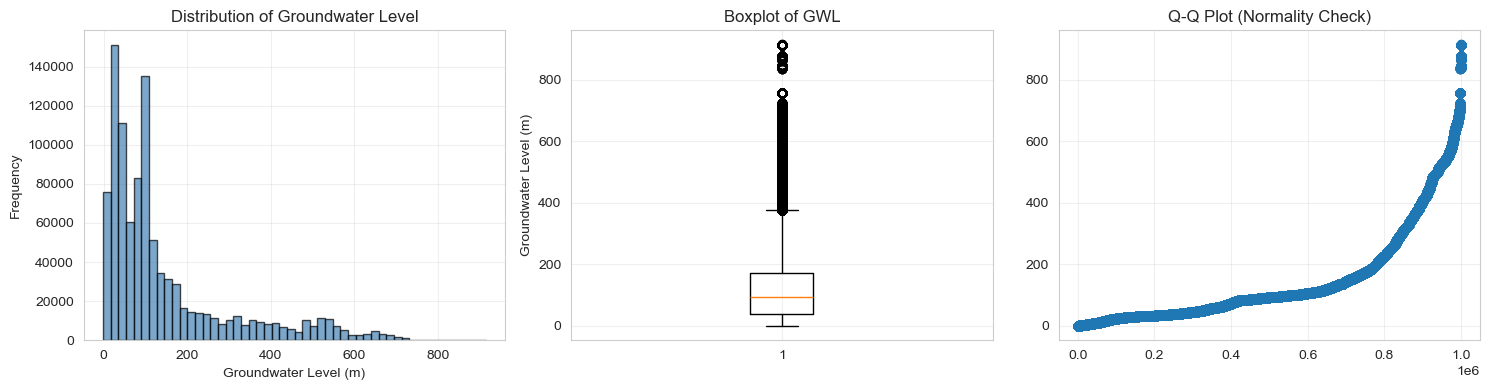


Target distribution: Skewed


In [ ]:
# Analyze the target variable
print("="*80)
print("TARGET VARIABLE STATISTICS")
print("="*80)
print(f"\nGroundwater Level (GWL) - Descriptive Statistics:")
print(f"  Count: {y.size}")
print(f"  Mean: {np.mean(y):.3f} m")
print(f"  Std Dev: {np.std(y):.3f} m")
print(f"  Min: {np.min(y):.3f} m")
print(f"  Median: {np.median(y):.3f} m")
print(f"  Max: {np.max(y):.3f} m")
print(f"  Q1 (25%): {np.percentile(y, 25):.3f} m")
print(f"  Q3 (75%): {np.percentile(y, 75):.3f} m")
print(f"  Missing values: {pd.isna(y).sum()}")

# Visualize the target distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(y, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Groundwater Level (m)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Groundwater Level')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(y, vert=True)
axes[1].set_ylabel('Groundwater Level (m)')
axes[1].set_title('Boxplot of GWL')
axes[1].grid(True, alpha=0.3)

# Plot of the sorted target
ysorted = sorted(y)
axes[2].set_title('Evoluation of underground water level')
axes[2].grid(True, alpha=0.3)
axes[2].scatter([x for x in range(len(y))], ysorted)

plt.tight_layout()
plt.show()

## 2. Feature Overview & Data Quality

FEATURE ANALYSIS

Numeric features: 57
Non-numeric features: 12

Non-numeric columns: ['well_id_str', 'date_dt', 'Proj_ID', 'Operator', 'AquiferMed', 'PreState', 'HUEK250_HU', 'HUEK250_RT', 'HUEK250_CT', 'HUEK250_DC', 'HUEK250_GC', 'HUMUS1000_OC']

Numeric Features Statistics:


,HYRAS_pr,HYRAS_tas,HYRAS_tasmax,HYRAS_tasmin,HYRAS_hurs,DWD_evapo_p,DWD_evapo_r,DWD_evapo_fao,DWD_soil_moist,DWD_soil_temp5cm,ERA5_sro,ERA5_ssro,ERA5_sdwe,ERA5_sm,ERA5_sf,Unnamed: 0,Elevation,Depth,UpFilter,LoFilter,ScrLength,Easting (EPSG:3035),Northing (EPSG:3035),HYRAUM_HD,HYRAUM_MHD,EU_MOHP_DSD_1,EU_MOHP_DSD_2,EU_MOHP_DSD_3,EU_MOHP_SD_1,EU_MOHP_SD_2,EU_MOHP_SD_3,EU_MOHP_LP_1,EU_MOHP_LP_2,EU_MOHP_LP_3,BUEK1000_RSA,GWN1000_GR,HUEK250_K,HYSOG_SG,SWR_PR,CLC_90,CLC_00,CLC_06,CLC_12,CLC_18,MUNDIALIS_LU,GMK1000_GU,DTM20_FD,DTM20_SL,DTM20_FA,DTM20_AS,DTM20_GC,DTM20_PLC,DTM20_PRC,DTM20_TPI,DTM20_TRI,DTM20_CI,DTM20_MRI
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1.000000e+06,1.000000e+06,1000000.000000,1000000.000000,706272.000000,448101.000000,448413.000000,574691.000000,1.000000e+06,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1000000.000000,1.000000e+06,1000000.000000,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,13.423484,10.033173,14.519668,5.472581,78.513466,1.808336,1.268717,1.909664,8.167278,11.525497,0.000433,0.004036,1.917849e-03,1.201935e-03,1.247569e-03,1604.012868,151.445389,33.991611,34.897617,38.888393,4.256387,4.355092e+06,3.095006e+06,33.042612,3.033570,1993.271696,4227.006563,8496.172837,1002.977250,1987.552218,3856.619139,4960.734561,4727.761113,4590.358773,25.082600,125.751887,4.814150,5.486990,206.241669,13.204827,13.183381,13.188664,13.183574,13.174233,13.174233,843.955358,2.888099,1.541399,1.178062e+07,3.111961,3.116713e+04,24.252069,-1.816974e-01,-0.203628,1.404707,2.020254,0.194532
std,14.399839,6.945271,8.236774,5.976295,9.419704,1.423131,0.890316,1.410374,2.045952,7.844549,0.001100,0.004520,9.861646e-03,4.513066e-03,3.818486e-03,925.780850,159.587616,57.698853,53.013229,54.837559,7.615178,1.549647e+05,1.988693e+05,22.153399,2.256871,1443.158302,2730.450452,5247.754289,1056.854797,1925.401184,3887.755043,3045.411741,3008.330433,3114.805562,18.586073,77.118970,3.087506,4.715842,158.610031,7.828876,7.930564,7.962107,8.095738,8.104327,8.104327,1140.360387,2.504496,0.079190,4.836090e+08,1.778720,2.180028e+06,709.237305,9.969011e+00,1.231210,2.332767,24.204899,0.522487
min,0.000000,-15.028572,-10.300001,-19.900000,41.342857,0.000000,0.000000,-0.471429,2.642857,-8.000000,0.000000,0.000000,-7.345365e-25,-3.725290e-09,-7.450581e-09,1.000000,-0.930000,0.010000,-22.797001,-23.797001,0.000000,4.051826e+06,2.702745e+06,11.000000,1.000000,0.000000,60.000000,115.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,-125.087585,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,111.000000,0.000000,0.349634,4.000000e+02,0.000005,-1.448026e+07,-1341.310791,-5.463545e+02,-21.346493,0.006886,-91.797150,0.000000
25%,2.800000,4.714286,7.800000,1.142857,72.171432,0.542857,0.528571,0.628571,6.271429,4.271429,0.000047,0.001250,-7.345365e-25,3.725290e-09,0.000000e+00,802.000000,44.099998,8.500000,7.500000,10.300000,1.500000,4.209254e+06,2.923267e+06,14.000000,1.000000,1017.000000,2303.000000,4505.000000,255.000000,514.000000,924.000000,2139.000000,1997.000000,1647.000000,11.000000,68.000000,3.000000,2.000000,113.833435,12.000000,10.000000,7.000000,3.000000,3.000000,3.000000,113.000000,0.000000,1.543101,8.458751e+02,1.570796,-2.565216e+01,-0.010350,-3.266010e-06,-0.203977,0.033221,-7.522772,0.000000
50%,9.300000,10.114286,15.014287,5.371428,79.328575,1.471429,1.085714,1.585714,8.628572,11.371428,0.000140,0.002453,-7.345365e-25,1.117587e-08,0.000000e+00,1

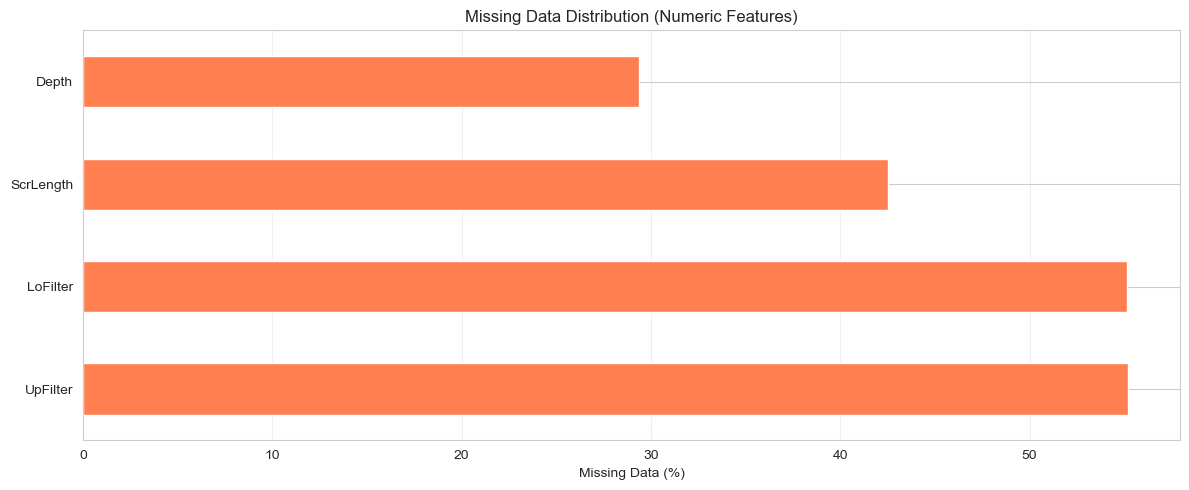


Data Quality Summary:
  Total missing values: 1822523
  Percentage of missing data: 2.64%


In [21]:
# Detailed feature analysis
print("="*80)
print("FEATURE ANALYSIS")
print("="*80)

# Separate numeric and non-numeric columns
numeric_cols = X_df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = X_df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\nNumeric features: {len(numeric_cols)}")
print(f"Non-numeric features: {len(non_numeric_cols)}")
print(f"\nNon-numeric columns: {non_numeric_cols}")

# Descriptive statistics for numeric features
print(f"\nNumeric Features Statistics:")
display(X_df[numeric_cols].describe())

# Missing data visualization
fig, ax = plt.subplots(figsize=(12, 5))
missing_data = (X_df[numeric_cols].isnull().sum() / len(X_df) * 100).sort_values(ascending=False)
missing_data_nonzero = missing_data[missing_data > 0]

if len(missing_data_nonzero) > 0:
    missing_data_nonzero.plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Missing Data (%)')
    ax.set_title('Missing Data Distribution (Numeric Features)')
    ax.grid(True, alpha=0.3, axis='x')
else:
    ax.text(0.5, 0.5, 'No missing data in numeric features', ha='center', va='center')
    ax.set_title('Missing Data Distribution')

plt.tight_layout()
plt.show()

print(f"\nData Quality Summary:")
print(f"  Total missing values: {X_df.isnull().sum().sum()}")
print(f"  Percentage of missing data: {(X_df.isnull().sum().sum() / (X_df.shape[0] * X_df.shape[1]) * 100):.2f}%")

## 3. Temporal and Spatial Patterns

TEMPORAL AND SPATIAL ANALYSIS

Date range: 2010-08-16 to 2016-08-01


C:\Users\charl\AppData\Local\Temp\ipykernel_20808\3987621940.py:25: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\charl\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


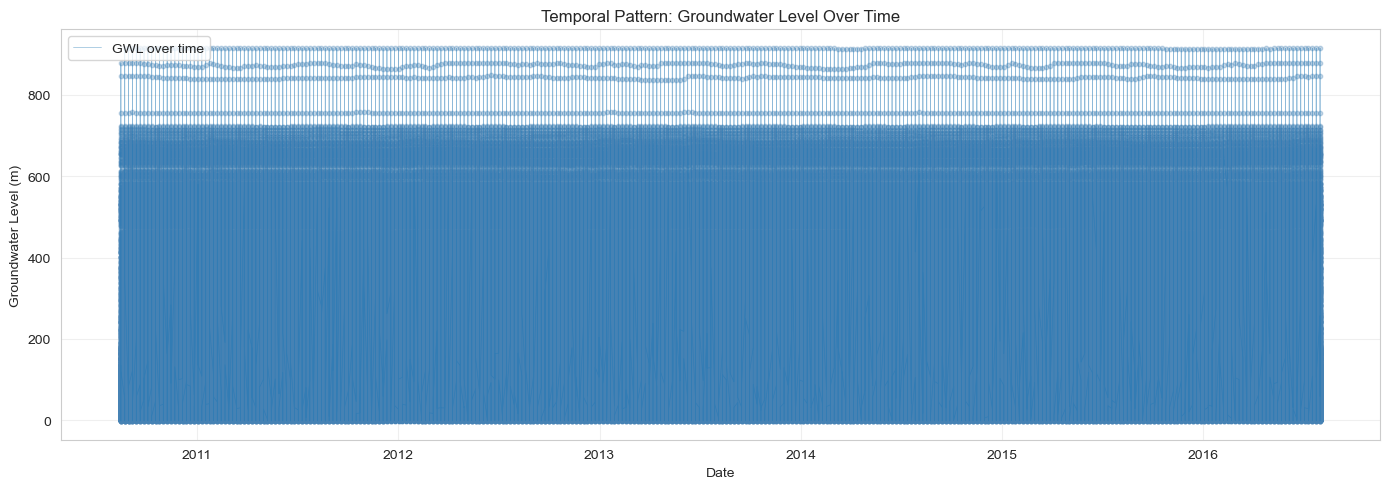


Number of unique wells: 3207
Samples per well - Mean: 311.8

Top 10 wells by number of samples:
well_id_str
MW_113     312
MW_843     312
MW_2804    312
MW_721     312
MW_1211    312
MW_233     312
MW_1865    312
MW_2610    312
MW_1564    312
MW_371     312
Name: count, dtype: int64


In [22]:
# Analyze temporal and spatial patterns
print("="*80)
print("TEMPORAL AND SPATIAL ANALYSIS")
print("="*80)

# Check for date and well_id columns
if 'date_dt' in X_df.columns:
    print(f"\nDate range: {X_df['date_dt'].min()} to {X_df['date_dt'].max()}")
    
    # Convert to datetime if not already
    X_df['date_dt'] = pd.to_datetime(X_df['date_dt'], errors='coerce')
    
    # Create temporal index
    df_temporal = pd.DataFrame({'date': X_df['date_dt'], 'gwl': y})
    df_temporal = df_temporal.sort_values('date')
    
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(df_temporal['date'], df_temporal['gwl'], alpha=0.5, linewidth=0.5, label='GWL over time')
    ax.scatter(df_temporal['date'], df_temporal['gwl'], alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel('Date')
    ax.set_ylabel('Groundwater Level (m)')
    ax.set_title('Temporal Pattern: Groundwater Level Over Time')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

if 'well_id_str' in X_df.columns:
    print(f"\nNumber of unique wells: {X_df['well_id_str'].nunique()}")
    print(f"Samples per well - Mean: {len(X_df) / X_df['well_id_str'].nunique():.1f}")
    
    # Top wells by number of samples
    well_counts = X_df['well_id_str'].value_counts()
    print(f"\nTop 10 wells by number of samples:")
    print(well_counts.head(10))

## 4. Feature Correlations

FEATURE CORRELATIONS WITH TARGET

Top 15 features most correlated with target:


,Feature,Correlation
16,Elevation,0.998862
22,Northing (EPSG:3035),-0.668498
38,SWR_PR,0.595287
24,HYRAUM_MHD,0.579648
23,HYRAUM_HD,0.570596
35,GWN1000_GR,0.490695
11,ERA5_ssro,0.351183
54,DTM20_TRI,0.309845
45,GMK1000_GU,0.281671
20,ScrLength,0.262487


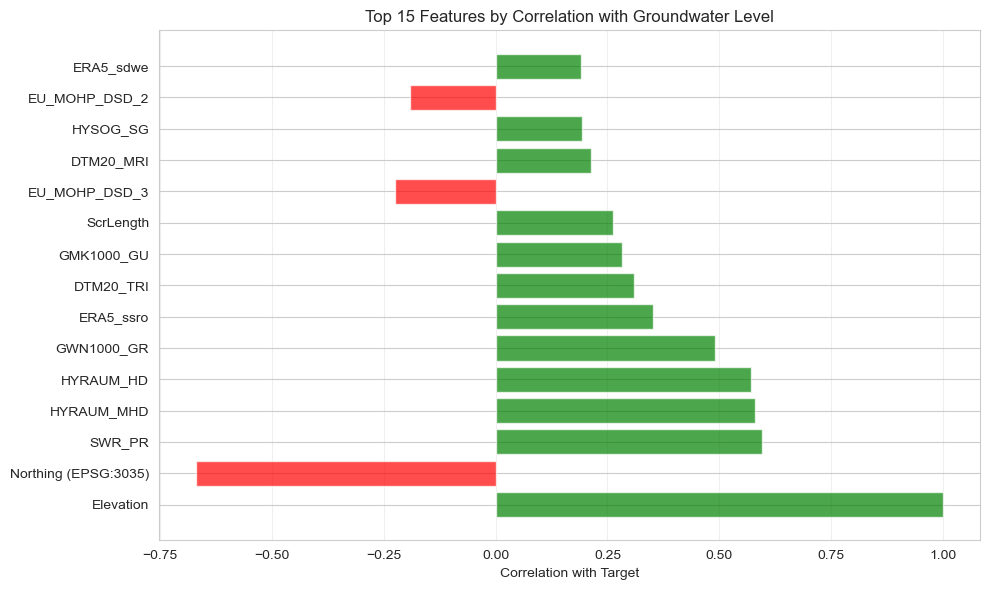

In [23]:
# Correlation analysis with target variable
print("="*80)
print("FEATURE CORRELATIONS WITH TARGET")
print("="*80)

# Calculate correlations with target
correlations = {}
for col in numeric_cols:
    valid_mask = ~(X_df[col].isnull() | pd.isna(y))
    if valid_mask.sum() > 0:
        corr = np.corrcoef(X_df.loc[valid_mask, col], y[valid_mask])[0, 1]
        if not np.isnan(corr):
            correlations[col] = corr

# Sort by absolute correlation
corr_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Correlation'])
corr_df['Abs_Correlation'] = np.abs(corr_df['Correlation'])
corr_df = corr_df.sort_values('Abs_Correlation', ascending=False)

print(f"\nTop 15 features most correlated with target:")
display(corr_df.head(15)[['Feature', 'Correlation']])

# Visualize top correlations
fig, ax = plt.subplots(figsize=(10, 6))
top_corr = corr_df.head(15)
colors = ['green' if x > 0 else 'red' for x in top_corr['Correlation']]
ax.barh(range(len(top_corr)), top_corr['Correlation'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr['Feature'])
ax.set_xlabel('Correlation with Target')
ax.set_title('Top 15 Features by Correlation with Groundwater Level')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 6. Key Insights

In [27]:
print("="*80)
print("KEY INSIGHTS")
print("="*80)
print(f"""
1. DATA CHARACTERISTICS:
   - Total samples: {len(X_df):,}
   - Number of features: {X_df.shape[1]}
   - Numeric features: {len(numeric_cols)}
   - Missing data: {(X_df.isnull().sum().sum() / (X_df.shape[0] * X_df.shape[1]) * 100):.2f}%

2. TARGET DISTRIBUTION:
   - Range: {y.min():.2f}m to {y.max():.2f}m
   - Mean: {y.mean():.2f}m ± {y.std():.2f}m
   - Distribution: {'Skewed' if abs(stats.skew(y)) > 0.5 else 'Approximately Normal'}

3. FEATURE RELATIONSHIPS:
   - Strongest predictor: {corr_df.iloc[0]['Feature']} (r={corr_df.iloc[0]['Correlation']:.3f})
   - Features with |correlation| > 0.3: {sum(corr_df['Abs_Correlation'] > 0.3)}
""")

KEY INSIGHTS

1. DATA CHARACTERISTICS:
   - Total samples: 1,000,000
   - Number of features: 69
   - Numeric features: 57
   - Missing data: 2.64%

2. TARGET DISTRIBUTION:
   - Range: -1.87m to 915.40m
   - Mean: 145.78m ± 157.65m
   - Distribution: Skewed

3. FEATURE RELATIONSHIPS:
   - Strongest predictor: Elevation (r=0.999)
   - Features with |correlation| > 0.3: 8



# Challenge Evaluation

To ensure the results are robust and reflect real-world forecasting capabilities, we evaluate submissions using a **Temporal Split** strategy.

#### 1. Evaluation Metric: RMSE

The primary metric for this challenge is the **Root Mean Squared Error (RMSE)**.


This metric is particularly suitable for groundwater prediction because it penalizes large errors more heavily than small ones, which is critical for water resource management and flood/drought prevention.

* **Lower is Better:** A perfect prediction would result in an RMSE of 0.
* **Units:** The RMSE is in the same units as the target variable (meters of depth to groundwater).

#### 2. Evaluation Strategy: Temporal Holdout

Unlike standard cross-validation where data is shuffled, groundwater levels are highly dependent on time and seasonal cycles. To simulate a real-world scenario where we predict the *future* based on the *past*:

* **Training Data:** Consists of the earliest **80%** of the historical timeline.
* **Test Data:** Consists of the most recent **20%** of the records.
* **Data Leakage Prevention:** By splitting strictly by date, we ensure the model cannot "see" future weather patterns or water levels during the training phase.

#### 3. Handling Metadata

Participants are provided with raw `well_id` and `date` columns. While these cannot be passed directly into a standard regressor (like Random Forest or XGBoost), they are essential for:

* **Seasonal Features:** Extracting month/year patterns.
* **Spatial Consistency:** Understanding that certain wells behave similarly due to shared geological characteristics.

Submissions must include a preprocessing step (ideally via a `scikit-learn` Pipeline) to manage these non-numeric columns.

---

## The Submission File

In this challenge, your submission is not a file of predictions, but the **code** itself. The ingestion program expects a file named `submission.py` containing a `get_model()` function.

### From DataFrames to Numeric Arrays

The input data provided by the competition is stored in a **Pandas DataFrame**. However, most machine learning models (like those in Scikit-Learn) require a **NumPy array** of floats to perform calculations. 

Because our dataset contains "metadata" columns like `well_id_str` (strings) and `date_dt` (dates), we cannot simply pass the whole DataFrame to the model. We must transform it first.

### Using Scikit-Learn `ColumnTransformer`

To bridge the gap between a messy DataFrame and a clean NumPy array, we use a `ColumnTransformer`. This tool allows us to apply different transformations to different columns. 

**The simplest strategy is to select only the numeric columns and drop the rest.**



### Example: Simple Column Selection

Here is how you can define a model that automatically filters out the string columns and only works with the numeric features:

```python
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector as selector
from sklearn.ensemble import RandomForestRegressor

def get_model():
    # 1. Define the ColumnTransformer
    # We use a selector to automatically pick columns with float or int types.
    # The 'remainder=drop' setting ensures that strings like well IDs are removed.
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', selector(dtype_include=['float64', 'int64']))
        ],
        remainder='drop'
    )

    # 2. Bundle the preprocessor and the regressor into a Pipeline
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=10, max_depth=5))
    ])
    
    return model

```

### Why use a Pipeline?

By using a `Pipeline`, you ensure that the same transformations applied to your **Training Data** are automatically applied to the **Test Data** during evaluation. This prevents "Dimension Mismatch" errors and ensures your model always receives the correct numeric input format.




### What this explains to your participants:

1.  **Data Format**: They now know the input is a DataFrame.
2.  **The "Why"**: They understand why they can't just throw the whole table at a model (because of the string columns).
3.  **The "How"**: They see a concrete example of using `selector` to pick only numbers, which is the most robust way to avoid the `ValueError` they would otherwise get.




In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector as selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

def get_model():
    """
    Returns a model that automatically filters out string columns 
    to avoid ValueErrors and fits on numeric data only.
    """
    
    # 1. Define a transformer that ONLY picks numeric columns (float64, int64)
    # This automatically ignores 'well_id_str' and 'date_dt' because they are strings/objects
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, selector(dtype_include=['float64', 'int64']))
        ],
        remainder='drop' # This explicitly drops anything that isn't a number
    )

    # 2. Create the full pipeline
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=50, max_depth=8, random_state=42))
    ])
    
    return model


## Local testing pipeline

Here you can show how the model will be used to generate predictions on the test set, and how the evaluation will be performed.

In [3]:
from solution.submission import get_model
model = get_model()
X_train, y_train = get_train_data("dev_phase/input_data")
model.fit(X_train, y_train)


Reading dev_phase/input_data/train/train.csv in chunks...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [ ]:

X_test = pd.read_csv("dev_phase/input_data/test/test_features.csv")
from ingestion_program.ingestion import evaluate_model
y_test = evaluate_model(model, X_test)
from scoring_program.scoring import compute_rmse
print("Accuracy on test set:", compute_rmse(y_test, pd.read_csv("path_to_test_labels"))) #the test data wouldn't be accesible keep in minde 

## Submission

Once you have refined your model in `solution/submission.py`, you need to upload it to the Codabench platform. 

### The Rules of the ZIP
Codabench is very strict about the structure of your upload:
1. Your ZIP file must contain `submission.py` at the **root level**.
2. If `submission.py` is hidden inside a folder within the ZIP, the platform will not find your `get_model()` function and your submission will fail.



### Using the Helper Script
To make this easy, we have provided a helper script called `zip_submission.py`. This script automatically finds your code and packages it into a `submission.zip` file with the correct internal structure.